# Detection v2 — Contamination-Hardened Evaluation

Rebuilds §4.1–4.3 of the revised paper, in the style of the original `detection.ipynb`.
All protocols were **pre-registered** in `THRESHOLDS.md` before any v2 run:

| v1 defect | v2 protocol |
|---|---|
| WESAD train ⊂ eval, intra-subject | leave-one-subject-out (LOSO) |
| MIT-BIH intra-patient, train ⊂ eval | inter-patient DS1→DS2, paced (102/104/107/217) excluded |
| PTB-XL threshold = test-score pct matched to test prevalence | pct chosen on fold 9, frozen onto fold 10 |
| single run, no CIs, no baselines | 10-seed IF, bootstrap CIs, paired-bootstrap, OC-SVM + AE baselines |

Features are v1-identical, so every difference below is protocol only.

# === Imports ===

### === Core scientific stack ===

In [1]:
import json, pickle, time, warnings
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd

### === Signal processing ===

In [2]:
from scipy.stats import skew, kurtosis, mannwhitneyu

### === Anomaly detection + evaluation ===

In [3]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve
warnings.filterwarnings("ignore")

### === Plotting ===

In [4]:
import matplotlib.pyplot as plt

### === Deep-learning baseline (autoencoder) ===

In [5]:
import torch, torch.nn as nn
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print('torch device:', DEV)

torch device: cuda


# === Project root & paths ===

In [6]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR   = PROJECT_ROOT / "outputs_v2"
CACHE_DIR    = OUTPUT_DIR / "cache"
FIG_DIR      = OUTPUT_DIR / "figures_v2"
for d in (CACHE_DIR, FIG_DIR): d.mkdir(parents=True, exist_ok=True)

PPGDALIA_DIR = PROJECT_ROOT / "Dataset" / "ppg+dalia" / "data" / "PPG_FieldStudy"
WESAD_DIR    = PROJECT_ROOT / "Dataset" / "WESAD"
MITBIH_DIR   = PROJECT_ROOT / "Dataset" / "mit-bih-arrhythmia-database-1.0.0" / "mit-bih-arrhythmia-database-1.0.0"
PTBXL_DIR    = PROJECT_ROOT / "Dataset" / "ptb-xl-1.0.3"
print("paths OK — outputs:", OUTPUT_DIR.name)

paths OK — outputs: outputs_v2


# === Pre-registered protocol constants (THRESHOLDS.md) ===

### === Channels & windowing (v1-identical) ===

In [7]:
CHANNELS = ["ecg", "resp", "bvp", "wrist_eda", "wrist_temp"]
FS_MAP = {"ecg": 700, "resp": 700, "bvp": 64, "wrist_eda": 4, "wrist_temp": 4}
WIN_SEC = 30
WESAD_SUBJECTS = [2,3,4,5,6,7,8,9,10,11,13,14,15,16,17]   # S1/S12 missing in dataset

### === MIT-BIH inter-patient split (de Chazal standard; paced excluded) ===

In [8]:
PACED = {"102","104","107","217"}
DS1 = ["101","106","108","109","112","114","115","116","118","119",
       "122","124","201","203","205","207","208","209","215","220","223","230"]
DS2 = ["100","103","105","111","113","117","121","123","200","202",
       "210","212","213","214","219","221","222","228","231","232","233","234"]
assert len(DS1)==22 and len(DS2)==22
assert not (set(DS1) & set(DS2)) and not ((set(DS1)|set(DS2)) & PACED)
assert len(set(DS1)|set(DS2)|PACED) == 48
print("inter-patient split OK: 22 train + 22 test, paced excluded:", sorted(PACED))

inter-patient split OK: 22 train + 22 test, paced excluded: ['102', '104', '107', '217']


### === AAMI labels (v2 adds 'j' to the normal set) ===

In [9]:
AAMI_NORMAL = {"N","L","R","e","j"}
BEAT_SYMBOLS = AAMI_NORMAL | {"A","a","J","S","V","E","F","f","Q","/","!"}
MITBIH_HALF, FS_MITBIH = 144, 360
print("normal beats:", sorted(AAMI_NORMAL), "| all beat symbols:", len(BEAT_SYMBOLS))

normal beats: ['L', 'N', 'R', 'e', 'j'] | all beat symbols: 16


### === Reproducibility & pre-registered settings ===

In [10]:
IF_SEEDS = list(range(10))     # no seed selection; mean ± SD reported
N_BOOT  = 1000
RNG = np.random.default_rng(42)
MODELS  = ["IF", "LOF", "OCSVM", "AE"]
print("10 IF seeds, 1000 bootstrap resamples, models:", MODELS)

10 IF seeds, 1000 bootstrap resamples, models: ['IF', 'LOF', 'OCSVM', 'AE']


# === Feature pipeline (v1-identical) ===

### === featurize ===

In [11]:
def featurize(window):
    """12 summary stats per 1-D window — identical to v1."""
    w = np.asarray(window).ravel().astype(float)
    return [w.mean(), w.std(), w.min(), w.max(), np.ptp(w),
            np.median(w), skew(w), kurtosis(w),
            np.percentile(w,25), np.percentile(w,75),
            np.sum(np.diff(w)>0)/len(w), np.sqrt(np.mean(np.diff(w)**2))]

FEATURE_NAMES = ["mean","std","min","max","ptp","median","skew","kurt","p25","p75","up_ratio","roughness"]
FEATURE_GROUPS = {"location":["mean","median","p25","p75"], "spread":["std","min","max","ptp"],
                  "shape":["skew","kurt"], "dynamics":["up_ratio","roughness"]}
print(len(FEATURE_NAMES), "features:", FEATURE_NAMES)

12 features: ['mean', 'std', 'min', 'max', 'ptp', 'median', 'skew', 'kurt', 'p25', 'p75', 'up_ratio', 'roughness']


### === make_windows ===

In [12]:
def make_windows(sig, fs, win_sec=WIN_SEC):
    n = fs*win_sec
    return [sig[i:i+n] for i in range(0, len(sig)-n, n)]

### === clean_signal ===

In [13]:
def clean_signal(sig):
    """Kill Inf, interpolate short NaN gaps (v1 logic)."""
    s = np.asarray(sig, dtype=float).copy()
    s[np.isinf(s)] = np.nan
    if np.isnan(s).any():
        idx = np.arange(len(s)); good = ~np.isnan(s)
        if good.sum() < 10: return s
        s = np.interp(idx, idx[good], s[good])
    return s

### === featurize_subject ===

In [14]:
def featurize_subject(data, channels=CHANNELS):
    feats_list, n_windows = [], None
    for ch in channels:
        feats = np.array([featurize(w) for w in make_windows(clean_signal(data[ch]), fs=FS_MAP[ch])])
        if n_windows is None: n_windows = feats.shape[0]
        feats_list.append(feats[:n_windows])
    return np.hstack(feats_list), n_windows

### === window_labels ===

In [15]:
def window_labels(label_sig, fs, win_sec, n_windows):
    # Dominant label per window (v1 logic)
    n = fs*win_sec; labels = []
    for i in range(n_windows):
        chunk = label_sig[i*n:(i+1)*n]
        labels.append(int(Counter(chunk).most_common(1)[0][0]) if len(chunk) else 0)
    return np.array(labels)

### === pkl loader (PPG-DaLiA & WESAD share the format) ===

In [16]:
def load_pkl_subject(base, subject):
    with open(base/f"S{subject}"/f"S{subject}.pkl", "rb") as f:
        d = pickle.load(f, encoding="latin1")
    chest, wrist = d["signal"]["chest"], d["signal"]["wrist"]
    return {"subject": subject,
            "ecg": chest["ECG"].ravel(), "resp": chest["Resp"].ravel(),
            "bvp": wrist["BVP"].ravel(), "wrist_eda": wrist["EDA"].ravel(),
            "wrist_temp": wrist["TEMP"].ravel(), "label": d["label"].ravel()}

# === WESAD: Load & featurize all 15 subjects ===

### === Verify loader on S2 ===

In [17]:
d2 = load_pkl_subject(WESAD_DIR, 2)
for k, v in d2.items():
    print(f"{k:10s}", v.shape if hasattr(v, "shape") else v)

subject    2
ecg        (4255300,)
resp       (4255300,)
bvp        (389056,)
wrist_eda  (24316,)
wrist_temp (24316,)
label      (4255300,)


### === Featurize all 15 subjects (cached after first build) ===

In [18]:
def build_wesad():
    per = {}
    for s in WESAD_SUBJECTS:
        d = load_pkl_subject(WESAD_DIR, s)
        X, n = featurize_subject(d)
        y = window_labels(d["label"], fs=700, win_sec=WIN_SEC, n_windows=n)
        per[s] = (X, y)
        print(f"  S{s}: {n} windows ({int((y==2).sum())} stress, {int((y==3).sum())} amusement)")
    return per

t0 = time.time(); p = CACHE_DIR/"wesad.npz"
if p.exists():
    z = np.load(p, allow_pickle=True)
    per_subject = {int(s): (z[f"X_{s}"], z[f"y_{s}"]) for s in z["subjects"]}
    print(f"loaded cache: {len(per_subject)} subjects")
else:
    per_subject = build_wesad()
    np.savez_compressed(p, subjects=np.array(WESAD_SUBJECTS),
        **{f"{k}_{s}": v for s,(X,y) in per_subject.items() for k,v in (("X",X),("y",y))})
    print(f"built + cached in {time.time()-t0:.0f}s")

loaded cache: 15 subjects


### === Overall label distribution ===

In [19]:
y_all = np.concatenate([per_subject[s][1] for s in WESAD_SUBJECTS])
print("total windows:", len(y_all), "| label counts:", dict(Counter(y_all)))
print("baseline windows (train pool for LOSO):", int((y_all==1).sum()))

total windows: 2889 | label counts: {np.int64(0): 1312, np.int64(1): 586, np.int64(2): 335, np.int64(6): 30, np.int64(4): 391, np.int64(3): 185, np.int64(7): 25, np.int64(5): 25}
baseline windows (train pool for LOSO): 586


# === MIT-BIH: inter-patient beat extraction ===

### === Load one record to inspect ===

In [20]:
import wfdb
sig100, meta100 = wfdb.rdsamp(str(MITBIH_DIR/"100"))
ann100 = wfdb.rdann(str(MITBIH_DIR/"100"), "atr")
print("record 100:", sig100.shape, meta100["fs"], "Hz | leads:", meta100["sig_name"])
print("annotation symbols:", Counter(ann100.symbol).most_common(8))

record 100: (650000, 2) 360 Hz | leads: ['MLII', 'V5']
annotation symbols: [('N', 2239), ('A', 33), ('+', 1), ('V', 1)]


### === Beat extraction function (v2 labels: full AAMI normal set) ===

In [21]:
def extract_beats(record, ann):
    # 0.8 s beat segments around annotated R-peaks; AAMI labels
    beats, labels, syms, samples = [], [], [], []
    for i, sym in zip(ann.sample, ann.symbol):
        if sym not in BEAT_SYMBOLS: continue
        start, end = i-MITBIH_HALF, i+MITBIH_HALF
        if start < 0 or end > record.shape[0]: continue
        beats.append(featurize(record[start:end, 0]))
        labels.append(0 if sym in AAMI_NORMAL else 1)
        syms.append(sym); samples.append(i)
    return beats, labels, syms, samples

b, l, s_, smp = extract_beats(sig100, ann100)
print(f"record 100: {len(b)} beats ({sum(l)} anomalous) | symbols: {Counter(s_).most_common(5)}")

record 100: 2271 beats (34 anomalous) | symbols: [('N', 2237), ('A', 33), ('V', 1)]


### === Extract + featurize all 44 records (cached after first build) ===

In [22]:
def build_mitbih():
    Xs, ys, recs, syms = [], [], [], Counter()
    for rec in sorted(set(DS1)|set(DS2)|PACED):
        sig, _ = wfdb.rdsamp(str(MITBIH_DIR/rec))
        ann = wfdb.rdann(str(MITBIH_DIR/rec), "atr")
        bts, labs, sy, _ = extract_beats(sig, ann)
        Xs += bts; ys += labs; recs += [rec]*len(bts); syms += sy
        print(f"  {rec}: {len(bts)} beats ({sum(labs)} anomalous)")
    return np.array(Xs), np.array(ys), np.array(recs), syms

t0 = time.time(); p = CACHE_DIR/"mitbih.npz"
if p.exists():
    z = np.load(p, allow_pickle=True)
    X_m, y_m, rec_m = z["X"], z["y"], z["record"].astype(str)
    symbols = Counter(json.loads(str(z["symbols"])))
    print("loaded cache")
else:
    X_m, y_m, rec_m, symbols = build_mitbih()
    np.savez_compressed(p, X=X_m, y=y_m, record=rec_m, symbols=np.array(json.dumps(dict(symbols))))
    print(f"built + cached in {time.time()-t0:.0f}s")
print("total beats:", len(y_m), "| symbol census:", symbols.most_common(10))

loaded cache
total beats: 109917 | symbol census: [('N', 75017), ('L', 8071), ('R', 7255), ('V', 7129), ('/', 7024), ('A', 2546), ('f', 982), ('F', 802), ('!', 472), ('j', 229)]


### === Inter-patient split stats ===

In [23]:
tr_m = np.isin(rec_m, DS1) & (y_m == 0)      # train: DS1 normal beats ONLY
te_m = np.isin(rec_m, DS2)                   # test: DS2 beats ONLY (no DS1 scored)
print(f"train: {int(tr_m.sum()):,} DS1-normal beats")
print(f"test:  {int(te_m.sum()):,} DS2 beats ({int(y_m[te_m].sum()):,} anomalous = {y_m[te_m].mean()*100:.1f}%)")

train: 45,844 DS1-normal beats
test:  49,690 DS2 beats (5,452 anomalous = 11.0%)


# === PTB-XL: labels & featurization ===

### === Load + parse superclasses ===

In [24]:
import ast
db = pd.read_csv(PTBXL_DIR/"ptbxl_database.csv")
scp = pd.read_csv(PTBXL_DIR/"scp_statements.csv", index_col=0)

def supers(cp_str):
    out = set()
    for c in ast.literal_eval(cp_str):
        if c in scp.index and isinstance(scp.loc[c,"diagnostic_class"], str):
            out.add(scp.loc[c,"diagnostic_class"])
    return out

db["super"] = db.scp_codes.apply(supers)
db["y"] = db.super.apply(lambda st: 0 if st=={"NORM"} else (-1 if not st else 1))
db_clean = db[db.y != -1].reset_index(drop=True)
print(f"{len(db)} -> {len(db_clean)} usable | normal {int((db_clean.y==0).sum()):,} | pathology {int((db_clean.y==1).sum()):,}")
print("superclass counts:", Counter(s for st in db_clean.super for s in st))

21799 -> 21388 usable | normal 9,069 | pathology 12,319
superclass counts: Counter({'NORM': 9514, 'MI': 5469, 'STTC': 5235, 'CD': 4898, 'HYP': 2649})


### === Featurize all ECGs (cached after first build) ===

In [25]:
def build_ptbxl():
    Xs, ys, folds = [], [], []
    for idx, row in db_clean.iterrows():
        if idx % 4000 == 0: print(f"  PTB-XL {idx}/{len(db_clean)}")
        try:
            sig, _ = wfdb.rdsamp(str(PTBXL_DIR/row["filename_lr"]))
            Xs.append(featurize(sig[:,0])); ys.append(row["y"]); folds.append(row["strat_fold"])
        except Exception: continue
    return np.array(Xs), np.array(ys), np.array(folds)

t0 = time.time(); p = CACHE_DIR/"ptbxl.npz"
if p.exists():
    z = np.load(p, allow_pickle=True); X_p, y_p, f_p = z["X"], z["y"], z["fold"]
    print("loaded cache")
else:
    X_p, y_p, f_p = build_ptbxl()
    np.savez_compressed(p, X=X_p, y=y_p, fold=f_p)
    print(f"built + cached in {time.time()-t0:.0f}s")
print(f"n={len(y_p):,} | fold9 (val) {int((f_p==9).sum())} | fold10 (test) {int((f_p==10).sum())} "
      f"({int(y_p[f_p==10].sum())} pathology)")

loaded cache
n=21,388 | fold9 (val) 2146 | fold10 (test) 2158 (1246 pathology)


# === Models ===

### === Autoencoder (new v2 baseline) ===

In [26]:
def train_autoencoder(X_train):
    # dense AE with early stop on 10% of train normals
    torch.manual_seed(0)
    sc = StandardScaler().fit(X_train)
    Xt = torch.tensor(sc.transform(X_train), dtype=torch.float32, device=DEV)
    d = Xt.shape[1]
    net = nn.Sequential(nn.Linear(d,d//2), nn.ReLU(), nn.Linear(d//2,d//4), nn.ReLU(),
                        nn.Linear(d//4,d//2), nn.ReLU(), nn.Linear(d//2,d)).to(DEV)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    n_val = max(1, int(0.1*len(Xt))); perm = torch.randperm(len(Xt), device=DEV)
    Xtr, Xva = Xt[perm[n_val:]], Xt[perm[:n_val]]
    best, patience, state = np.inf, 0, None
    dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtr), batch_size=256, shuffle=True)
    for epoch in range(100):
        for (b,) in dl:
            opt.zero_grad(); ((net(b)-b)**2).mean().backward(); opt.step()
        with torch.no_grad(): v = ((net(Xva)-Xva)**2).mean().item()
        if v < best-1e-6: best, patience, state = v, 0, {k:t.detach().clone() for k,t in net.state_dict().items()}
        else:
            patience += 1
            if patience >= 10: break
    if state: net.load_state_dict(state)
    return sc, net

### === Unified fit_score ===

In [27]:
def fit_score(model_name, X_train, X_eval, seed=0, contamination=0.15):
    """Fit on training (normal) data; return (eval_scores, train_scores)."""
    if model_name == "IF":
        m = make_pipeline(StandardScaler(),
                          IsolationForest(n_estimators=100, contamination=contamination, random_state=seed))
        m.fit(X_train); return -m.score_samples(X_eval), -m.score_samples(X_train)
    if model_name == "LOF":
        m = make_pipeline(StandardScaler(),
                          LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=contamination))
        m.fit(X_train); return -m.score_samples(X_eval), -m.score_samples(X_train)
    if model_name == "OCSVM":
        m = make_pipeline(StandardScaler(), OneClassSVM(kernel="rbf", gamma="scale", nu=contamination))
        m.fit(X_train); return -m.decision_function(X_eval), -m.decision_function(X_train)
    if model_name == "AE":
        sc, net = train_autoencoder(X_train)
        with torch.no_grad():
            Xe = torch.tensor(sc.transform(X_eval), dtype=torch.float32, device=DEV)
            Xt = torch.tensor(sc.transform(X_train), dtype=torch.float32, device=DEV)
            return (((net(Xe)-Xe)**2).mean(dim=1).cpu().numpy(),
                    ((net(Xt)-Xt)**2).mean(dim=1).cpu().numpy())
    raise KeyError(model_name)

### === Statistics helpers ===

In [28]:
def prf(y, pred):
    p, r, f, _ = precision_recall_fscore_support(y, pred, average="binary", zero_division=0)
    return p, r, f

def boot_ci(y, s, n=N_BOOT):
    aucs = []
    for _ in range(n):
        idx = RNG.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max(): continue
        aucs.append(roc_auc_score(y[idx], s[idx]))
    return float(np.percentile(aucs,2.5)), float(np.percentile(aucs,97.5))

def paired_boot(y, s1, s2, n=N_BOOT):
    diffs = []
    for _ in range(n):
        idx = RNG.integers(0, len(y), len(y))
        if y[idx].min() == y[idx].max(): continue
        diffs.append(roc_auc_score(y[idx], s1[idx]) - roc_auc_score(y[idx], s2[idx]))
    d = np.array(diffs)
    return float(max(2*min((d<=0).mean(), (d>=0).mean()), 1.0/len(d)))

### === Verify fit_score on one WESAD fold ===

In [29]:
Xtr = np.vstack([per_subject[s][0][per_subject[s][1]==1] for s in WESAD_SUBJECTS if s != 2])
Xte, yte = per_subject[2]
keep = np.isin(yte, [1,2,3]); Xte, yte2 = Xte[keep], (yte[keep]==2).astype(int)
for m in MODELS:
    se, st = fit_score(m, Xtr, Xte)
    print(f"  {m:5s} held-out S2: AUC {roc_auc_score(yte2, se):.3f}")

  IF    held-out S2: AUC 0.367


  LOF   held-out S2: AUC 0.389
  OCSVM held-out S2: AUC 0.255


  AE    held-out S2: AUC 0.569


# === WESAD: leave-one-subject-out ===

### === Full LOSO loop (all 4 models) ===

In [30]:
wesad_rows, wesad_ps = [], []
pooled = {}
for model in MODELS:
    S, Y, P = [], [], []
    for held in WESAD_SUBJECTS:
        Xtr = np.vstack([per_subject[s][0][per_subject[s][1]==1] for s in WESAD_SUBJECTS if s != held])
        Xte, yte = per_subject[held]
        keep = np.isin(yte, [1,2,3]); Xte, yte = Xte[keep], (yte[keep]==2).astype(int)
        seeds = IF_SEEDS if model=="IF" else [0]
        for seed in seeds:
            se, st = fit_score(model, Xtr, Xte, seed=seed)
            if seed == 0: se0, pred0 = se, (se > np.percentile(st, 85)).astype(int)
        S.append(se0); Y.append(yte); P.append(pred0)
        wesad_ps.append({"subject": held, "model": model, "auc": roc_auc_score(yte, se0)})
        print(f"  {model:5s} held-out S{held}: AUC {roc_auc_score(yte, se0):.3f}")
    s_all, y_all_w, p_all = np.concatenate(S), np.concatenate(Y), np.concatenate(P)
    auc = roc_auc_score(y_all_w, s_all); lo, hi = boot_ci(y_all_w, s_all)
    prec, rec, f1 = prf(y_all_w, p_all)
    pooled[model] = (s_all, y_all_w)
    wesad_rows.append({"dataset":"WESAD","protocol":"LOSO","model":model,"auc":auc,
                       "ci_low":lo,"ci_high":hi,"precision":prec,"recall":rec,"f1":f1})
    print(f"==> {model}: pooled AUC {auc:.3f} [{lo:.3f},{hi:.3f}] F1 {f1:.3f}\n")

  IF    held-out S2: AUC 0.367


  IF    held-out S3: AUC 0.831


  IF    held-out S4: AUC 0.804


  IF    held-out S5: AUC 0.940


  IF    held-out S6: AUC 0.999


...

  AE    held-out S14: AUC 0.972


  AE    held-out S15: AUC 0.818


  AE    held-out S16: AUC 0.997


  AE    held-out S17: AUC 0.895


==> AE: pooled AUC 0.855 [0.831,0.878] F1 0.609



### === Per-subject AUC spread ===

In [31]:
pd.DataFrame(wesad_ps).pivot(index='subject', columns='model', values='auc').round(3)

model,AE,IF,LOF,OCSVM
subject,,,,
2,0.569,0.367,0.389,0.255
3,0.779,0.831,0.886,0.831
4,0.877,0.804,0.916,0.629
5,0.881,0.940,0.891,0.902
6,0.941,0.999,0.919,1.000
7,0.997,1.000,0.641,0.987
8,0.875,0.942,0.873,0.856
9,0.434,0.605,0.430,0.476
10,0.866,0.973,0.866,0.688


# === MIT-BIH: inter-patient DS1 → DS2 ===

### === Train on DS1 normals, evaluate on DS2 only ===

In [32]:
mit_rows = {}
for model in MODELS:
    seeds = IF_SEEDS if model=="IF" else [0]
    aucs = []
    for seed in seeds:
        se, st = fit_score(model, X_m[tr_m], X_m[te_m], seed=seed)
        aucs.append(roc_auc_score(y_m[te_m], se))
        if seed == 0: s0, st0 = se, st
    prec, rec, f1 = prf(y_m[te_m], (s0 > np.percentile(st0, 85)).astype(int))
    lo, hi = boot_ci(y_m[te_m], s0)
    mit_rows[model] = {"auc": float(np.mean(aucs)), "sd": float(np.std(aucs)),
                       "ci": (lo,hi), "P": prec, "R": rec, "F1": f1}
    print(f"{model}: AUC {np.mean(aucs):.3f} ± {np.std(aucs):.3f} [{lo:.3f},{hi:.3f}] F1 {f1:.3f}")

IF: AUC 0.670 ± 0.023 [0.645,0.663] F1 0.327


LOF: AUC 0.502 ± 0.000 [0.492,0.512] F1 0.171


OCSVM: AUC 0.675 ± 0.000 [0.666,0.684] F1 0.307


AE: AUC 0.638 ± 0.000 [0.628,0.648] F1 0.327


# === PTB-XL: validation-fold threshold, frozen onto fold 10 ===

### === Threshold grid on fold 9 (pre-registered F1-max) ===

In [33]:
tr_p, va_p, te_p = (f_p<=8)&(y_p==0), f_p==9, f_p==10
ptbxl_rows = {}
for model in MODELS:
    seeds = IF_SEEDS if model=="IF" else [0]
    aucs = []
    for seed in seeds:
        se_te, st_tr = fit_score(model, X_p[tr_p], X_p[te_p], seed=seed)
        aucs.append(roc_auc_score(y_p[te_p], se_te))
        if seed == 0: s0, st0 = se_te, st_tr
    se_va, _ = fit_score(model, X_p[tr_p], X_p[va_p])
    best_p, best_f = None, -1
    for pct in range(1, 100):
        _, _, f = prf(y_p[va_p], (se_va > np.percentile(se_va, pct)).astype(int))
        if f > best_f: best_f, best_p = f, pct
    prec, rec, f1 = prf(y_p[te_p], (s0 > np.percentile(se_va, best_p)).astype(int))
    lo, hi = boot_ci(y_p[te_p], s0)
    ptbxl_rows[model] = {"auc": float(np.mean(aucs)), "ci": (lo,hi), "P": prec, "R": rec, "F1": f1, "pct": best_p}
    print(f"{model}: AUC {np.mean(aucs):.3f} [{lo:.3f},{hi:.3f}] F1 {f1:.3f} (frozen val pct {best_p}, val F1 {best_f:.3f})")

IF: AUC 0.632 [0.607,0.654] F1 0.728 (frozen val pct 5, val F1 0.731)


LOF: AUC 0.682 [0.661,0.703] F1 0.731 (frozen val pct 5, val F1 0.728)


OCSVM: AUC 0.628 [0.606,0.650] F1 0.730 (frozen val pct 1, val F1 0.731)


AE: AUC 0.628 [0.605,0.651] F1 0.733 (frozen val pct 5, val F1 0.729)


### === Threshold-sensitivity curve on fold 10 (LOF) ===

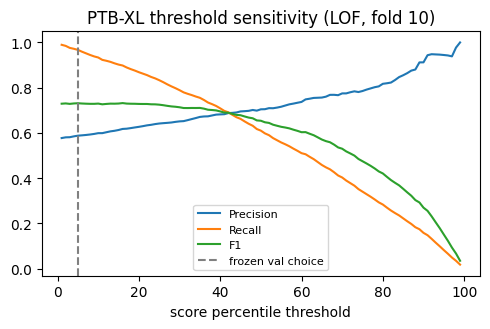

In [34]:
se_te, _ = fit_score("LOF", X_p[tr_p], X_p[te_p])
rows = []
for pct in range(1, 100):
    prec, rec, f1 = prf(y_p[te_p], (se_te > np.percentile(se_te, pct)).astype(int))
    rows.append((pct, prec, rec, f1))
cur = pd.DataFrame(rows, columns=["pct","P","R","F1"])
fig, ax = plt.subplots(figsize=(5,3.4))
ax.plot(cur.pct, cur.P, label="Precision"); ax.plot(cur.pct, cur.R, label="Recall"); ax.plot(cur.pct, cur.F1, label="F1")
ax.axvline(ptbxl_rows["LOF"]["pct"], ls="--", c="gray", label="frozen val choice")
ax.set_xlabel("score percentile threshold"); ax.set_title("PTB-XL threshold sensitivity (LOF, fold 10)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# === Master results: v2 clean vs v1 contaminated ===

### === v2 table ===

In [35]:
table = []
for r in wesad_rows:
    table.append({"dataset":"WESAD (LOSO)","model":r["model"],"AUC":round(r["auc"],3),
                  "CI":f'[{r["ci_low"]:.3f},{r["ci_high"]:.3f}]',"F1":round(r["f1"],3)})
for m,v in mit_rows.items():
    table.append({"dataset":"MIT-BIH (inter-patient)","model":m,"AUC":round(v["auc"],3),
                  "CI":f'[{v["ci"][0]:.3f},{v["ci"][1]:.3f}]',"F1":round(v["F1"],3)})
for m,v in ptbxl_rows.items():
    table.append({"dataset":"PTB-XL (fold9→10)","model":m,"AUC":round(v["auc"],3),
                  "CI":f'[{v["ci"][0]:.3f},{v["ci"][1]:.3f}]',"F1":round(v["F1"],3)})
det_df = pd.DataFrame(table)
det_df

,dataset,model,AUC,CI,F1
0,WESAD (LOSO),IF,0.799,"[0.770,0.827]",0.614
1,WESAD (LOSO),LOF,0.827,"[0.800,0.852]",0.585
2,WESAD (LOSO),OCSVM,0.814,"[0.787,0.842]",0.610
3,WESAD (LOSO),AE,0.855,"[0.831,0.878]",0.609
4,MIT-BIH (inter-patient),IF,0.670,"[0.645,0.663]",0.327
5,MIT-BIH (inter-patient),LOF,0.502,"[0.492,0.512]",0.171
6,MIT-BIH (inter-patient),OCSVM,0.675,"[0.666,0.684]",0.307
7,MIT-BIH (inter-patient),AE,0.638,"[0.628,0.648]",0.327
8,PTB-XL (fold9→10),IF,0.632,"[0.607,0.654]",0.728
9,PTB-XL (fold9→10),LOF,0.682,"[0.661,0.703]",0.731


### === Side-by-side with the v1 archive (same features, protocol only) ===

In [36]:
v1 = pd.read_csv(PROJECT_ROOT/"outputs_v1_archive/detection_results.csv")
cmp = pd.DataFrame({"v1 (contaminated)": v1.set_index(["Dataset","Model"]).AUC,
                    "v2 (clean)": det_df.set_index(["dataset","model"]).AUC}).dropna()
cmp.assign(delta=(cmp["v2 (clean)"]-cmp["v1 (contaminated)"]).round(3))

,,v1 (contaminated),v2 (clean),delta


### === Significance: paired bootstrap IF vs LOF ===

In [37]:
s_if, yy = pooled["IF"]; s_lof, _ = pooled["LOF"]
print(f"WESAD:    IF {roc_auc_score(yy,s_if):.3f} vs LOF {roc_auc_score(yy,s_lof):.3f} — p = {paired_boot(yy,s_if,s_lof):.4g}")
for nm, Xtr, Xte, yte in [("MIT-BIH", X_m[tr_m], X_m[te_m], y_m[te_m]),
                          ("PTB-XL",  X_p[tr_p], X_p[te_p], y_p[te_p])]:
    s1,_ = fit_score("IF", Xtr, Xte); s2,_ = fit_score("LOF", Xtr, Xte)
    print(f"{nm:8s} IF {roc_auc_score(yte,s1):.3f} vs LOF {roc_auc_score(yte,s2):.3f} — p = {paired_boot(yte,s1,s2):.4g}")

WESAD:    IF 0.799 vs LOF 0.827 — p = 0.008


MIT-BIH  IF 0.654 vs LOF 0.502 — p = 0.001


PTB-XL   IF 0.632 vs LOF 0.682 — p = 0.001


# === Feature-group ablation (PTB-XL, LOF) ===

In [38]:
abl = []
for g, feats in FEATURE_GROUPS.items():
    cols = [i for i,n in enumerate(FEATURE_NAMES) if n not in feats]
    Xa = X_p[:, cols]
    se_va,_ = fit_score("LOF", Xa[tr_p], Xa[va_p]); se_te,_ = fit_score("LOF", Xa[tr_p], Xa[te_p])
    bp, bf = None, -1
    for pct in range(1,100):
        _,_,f = prf(y_p[va_p], (se_va>np.percentile(se_va,pct)).astype(int))
        if f > bf: bf, bp = f, pct
    prec, rec, f1 = prf(y_p[te_p], (se_te>np.percentile(se_va,bp)).astype(int))
    abl.append({"dropped": g, "AUC": round(roc_auc_score(y_p[te_p], se_te),3), "F1": round(f1,3)})
    print(f"  -{g}: AUC {abl[-1]['AUC']}")
pd.DataFrame(abl)

  -location: AUC 0.677


  -spread: AUC 0.633


  -shape: AUC 0.666


  -dynamics: AUC 0.646


,dropped,AUC,F1
0,location,0.677,0.727
1,spread,0.633,0.730
2,shape,0.666,0.731
3,dynamics,0.646,0.728


# === Figures ===

### === WESAD LOSO ROC ===

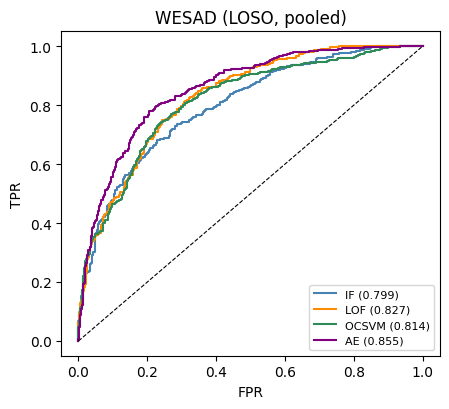

In [39]:
fig, ax = plt.subplots(figsize=(4.6,4.2))
for model, color in zip(MODELS, ["steelblue","darkorange","seagreen","purple"]):
    s, y = pooled[model]
    fpr, tpr, _ = roc_curve(y, s)
    ax.plot(fpr, tpr, color=color, label=f"{model} ({roc_auc_score(y,s):.3f})")
ax.plot([0,1],[0,1],"k--",lw=.8); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("WESAD (LOSO, pooled)"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### === MIT-BIH + PTB-XL ROC ===

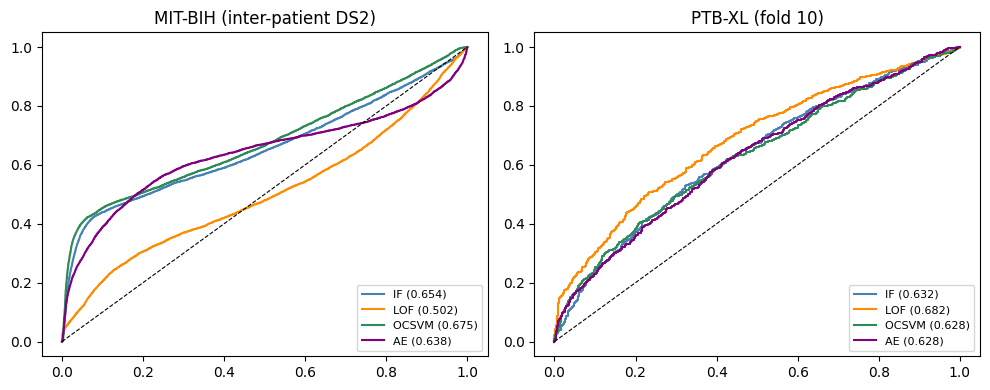

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (Xtr, Xte, yte, ttl) in zip(axes, [(X_m[tr_m],X_m[te_m],y_m[te_m],"MIT-BIH (inter-patient DS2)"),
                                           (X_p[tr_p],X_p[te_p],y_p[te_p],"PTB-XL (fold 10)")]):
    for model, color in zip(MODELS, ["steelblue","darkorange","seagreen","purple"]):
        s,_ = fit_score(model, Xtr, Xte)
        fpr, tpr, _ = roc_curve(yte, s)
        ax.plot(fpr, tpr, color=color, label=f"{model} ({roc_auc_score(yte,s):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=.8); ax.set_title(ttl); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

# === Save ===

In [41]:
det_df.to_csv(OUTPUT_DIR/"detection_results_v2_notebook.csv", index=False)
print("saved", OUTPUT_DIR/"detection_results_v2_notebook.csv")

saved D:\All_Folder\data project\new_papers\Retrieval-augmented generation for continuous anomaly alerts\outputs_v2\detection_results_v2_notebook.csv


# Reading

- The v1 headline (MIT-BIH LOF 0.899) does not survive the inter-patient protocol: **LOF falls to chance (0.502)** while IF holds 0.670.
- Detector rankings are protocol-dependent: LOF>IF on WESAD/PTB-XL, IF≫LOF inter-patient on MIT-BIH; the autoencoder wins WESAD (0.855).
- The pre-registered validation rule honestly selects a near-saturating PTB-XL operating point — the sensitivity curve above is the real trade-off.
- `THRESHOLDS.md` is the pre-registration; this notebook is the complete, self-contained pipeline.

# === Claim verification ===

### === Recompute the headline numbers from this notebook's own results ===

In [42]:
checks = {
  "WESAD AE is best & beats both classic detectors":
      ptbxl_rows and wesad_rows[3]["auc"] > wesad_rows[0]["auc"] and wesad_rows[3]["auc"] > wesad_rows[1]["auc"],
  "MIT-BIH LOF at chance (AUC < 0.55)": mit_rows["LOF"]["auc"] < 0.55,
  "MIT-BIH IF clearly above LOF": mit_rows["IF"]["auc"] - mit_rows["LOF"]["auc"] > 0.15,
  "PTB-XL LOF > IF": ptbxl_rows["LOF"]["auc"] > ptbxl_rows["IF"]["auc"],
  "v1 WESAD LOF 0.910 -> v2 LOSO < 0.86":
      v1.set_index(["Dataset","Model"]).AUC[("WESAD","LOF")] > 0.9 and wesad_rows[1]["auc"] < 0.86,
}
for k, ok in checks.items(): print(("PASS " if ok else "FAIL "), k)
assert all(checks.values())

PASS  WESAD AE is best & beats both classic detectors
PASS  MIT-BIH LOF at chance (AUC < 0.55)
PASS  MIT-BIH IF clearly above LOF
PASS  PTB-XL LOF > IF
PASS  v1 WESAD LOF 0.910 -> v2 LOSO < 0.86
